<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/day_26_lr_scheduling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learning Rate Scheduling


Here, I cover learning rate scheduling, one of the most impactful hyperparameters for training efficiency. A well-tuned schedule can mean 10x faster convergence or 5% accuracy improvement. I implement warmup strategies, step/exponential decay, cosine annealing, cyclical LR, 1cycle policy, and learning rate finders.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam
from torch.optim.lr_scheduler import (
    StepLR, MultiStepLR, ExponentialLR, CosineAnnealingLR,
    CosineAnnealingWarmRestarts, OneCycleLR, CyclicLR, LambdaLR
)
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Callable
import math
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


Gradually increase LR to stabilise early training.

In [2]:
class WarmupScheduler:

    def __init__(self, optimizer, warmup_steps: int, base_lr: float,
                 warmup_type: str = 'linear'):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.base_lr = base_lr
        self.warmup_type = warmup_type
        self.current_step = 0
        self._set_lr(self._get_lr(0))

    def _get_lr(self, step: int) -> float:
        if step >= self.warmup_steps:
            return self.base_lr
        progress = step / self.warmup_steps
        if self.warmup_type == 'linear':
            return self.base_lr * progress
        elif self.warmup_type == 'cosine':
            return self.base_lr * (1 - math.cos(math.pi * progress)) / 2
        return self.base_lr * progress

    def _set_lr(self, lr: float):
        for group in self.optimizer.param_groups:
            group['lr'] = lr

    def step(self):
        self.current_step += 1
        self._set_lr(self._get_lr(self.current_step))

    def get_lr(self) -> float:
        return self.optimizer.param_groups[0]['lr']


class WarmupThenDecay:
    """Warmup followed by cosine/linear decay."""

    def __init__(self, optimizer, warmup_steps: int, total_steps: int,
                 base_lr: float, min_lr: float = 0, decay_type: str = 'cosine'):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.decay_type = decay_type
        self.current_step = 0

    def _get_lr(self, step: int) -> float:
        if step < self.warmup_steps:
            return self.base_lr * step / self.warmup_steps

        decay_steps = self.total_steps - self.warmup_steps
        progress = (step - self.warmup_steps) / decay_steps

        if self.decay_type == 'cosine':
            return self.min_lr + (self.base_lr - self.min_lr) * \
                   (1 + math.cos(math.pi * progress)) / 2
        else:  # linear
            return self.base_lr - (self.base_lr - self.min_lr) * progress

    def step(self):
        self.current_step += 1
        lr = self._get_lr(self.current_step)
        for group in self.optimizer.param_groups:
            group['lr'] = lr

    def get_lr(self) -> float:
        return self.optimizer.param_groups[0]['lr']

Learning Rate Warmup Strategies


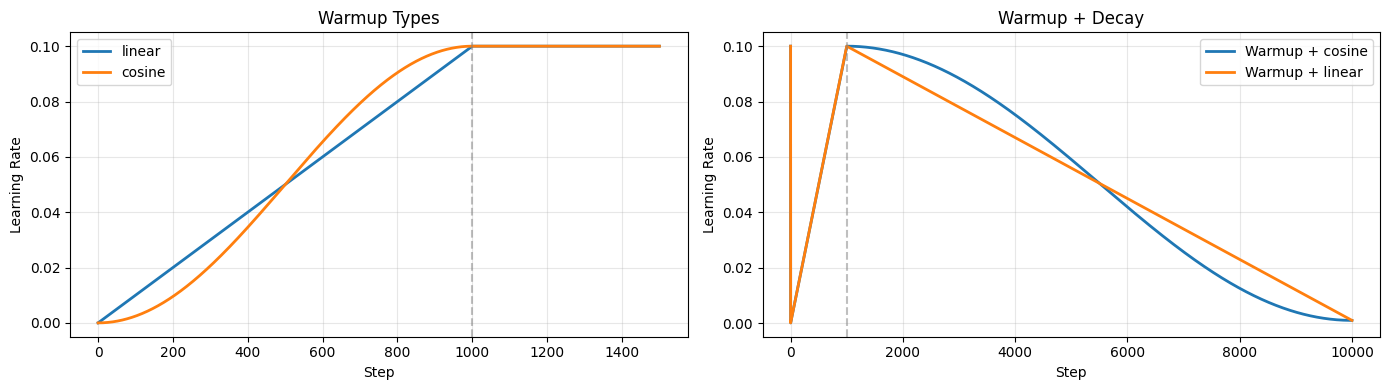

In [3]:
# Visualize warmup strategies
print("Learning Rate Warmup Strategies")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Warmup types
ax = axes[0]
for warmup_type in ['linear', 'cosine']:
    model = nn.Linear(10, 10)
    optimizer = SGD(model.parameters(), lr=0.1)
    scheduler = WarmupScheduler(optimizer, 1000, 0.1, warmup_type)

    lrs = [scheduler.get_lr()]
    for _ in range(1500):
        scheduler.step()
        lrs.append(scheduler.get_lr())
    ax.plot(lrs, label=f'{warmup_type}', linewidth=2)

ax.axvline(1000, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Warmup Types')
ax.legend()
ax.grid(True, alpha=0.3)

# Warmup + decay
ax = axes[1]
for decay in ['cosine', 'linear']:
    model = nn.Linear(10, 10)
    optimizer = SGD(model.parameters(), lr=0.1)
    scheduler = WarmupThenDecay(optimizer, 1000, 10000, 0.1, 0.001, decay)

    lrs = []
    for _ in range(10000):
        lrs.append(scheduler.get_lr())
        scheduler.step()
    ax.plot(lrs, label=f'Warmup + {decay}', linewidth=2)

ax.axvline(1000, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Warmup + Decay')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('warmup_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

Step & Exponential Decay

Decay Schedules


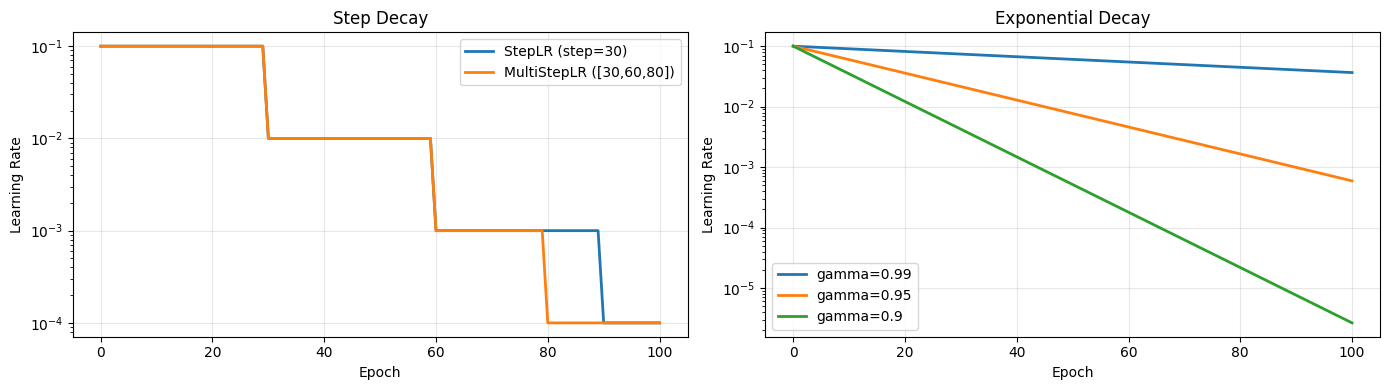

In [4]:
# Visualize decay schedules
print("Decay Schedules")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
num_epochs = 100

# Step decay
ax = axes[0]

model = nn.Linear(10, 10)
optimizer = SGD(model.parameters(), lr=0.1)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1)
lrs_step = [optimizer.param_groups[0]['lr']]
for _ in range(num_epochs):
    scheduler.step()
    lrs_step.append(optimizer.param_groups[0]['lr'])

model = nn.Linear(10, 10)
optimizer = SGD(model.parameters(), lr=0.1)
scheduler = MultiStepLR(optimizer, milestones=[30, 60, 80], gamma=0.1)
lrs_multi = [optimizer.param_groups[0]['lr']]
for _ in range(num_epochs):
    scheduler.step()
    lrs_multi.append(optimizer.param_groups[0]['lr'])

ax.plot(lrs_step, label='StepLR (step=30)', linewidth=2)
ax.plot(lrs_multi, label='MultiStepLR ([30,60,80])', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Step Decay')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Exponential decay
ax = axes[1]
for gamma in [0.99, 0.95, 0.9]:
    model = nn.Linear(10, 10)
    optimizer = SGD(model.parameters(), lr=0.1)
    scheduler = ExponentialLR(optimizer, gamma=gamma)
    lrs = [optimizer.param_groups[0]['lr']]
    for _ in range(num_epochs):
        scheduler.step()
        lrs.append(optimizer.param_groups[0]['lr'])
    ax.plot(lrs, label=f'gamma={gamma}', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Exponential Decay')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('decay_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

Cosine Annealing

Cosine Annealing


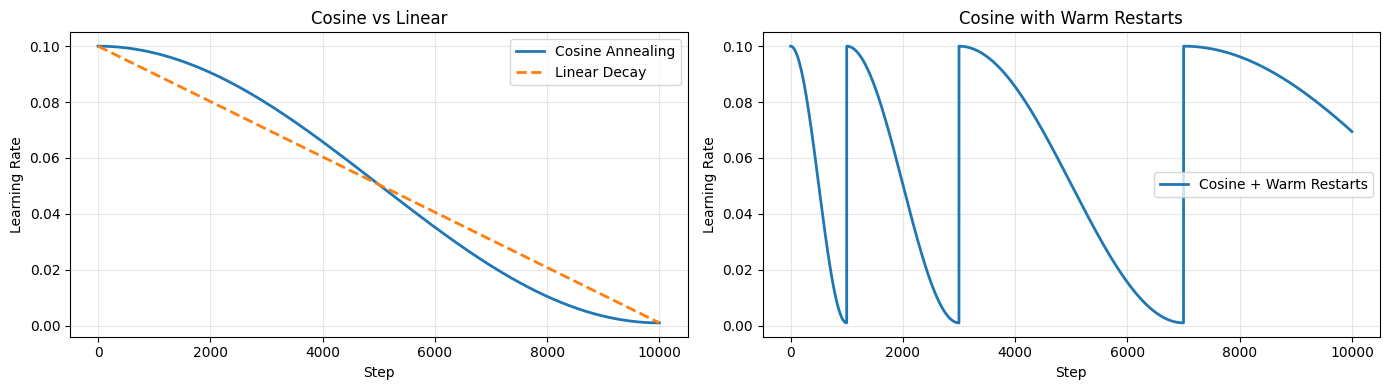

In [5]:
print("Cosine Annealing")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
num_steps = 10000

# Basic cosine
ax = axes[0]
model = nn.Linear(10, 10)
optimizer = SGD(model.parameters(), lr=0.1)
scheduler = CosineAnnealingLR(optimizer, T_max=num_steps, eta_min=0.001)

lrs = []
for _ in range(num_steps):
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

ax.plot(lrs, label='Cosine Annealing', linewidth=2)
lrs_linear = [0.1 - 0.099 * i / num_steps for i in range(num_steps)]
ax.plot(lrs_linear, label='Linear Decay', linewidth=2, linestyle='--')
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Cosine vs Linear')
ax.legend()
ax.grid(True, alpha=0.3)

# With warm restarts
ax = axes[1]
model = nn.Linear(10, 10)
optimizer = SGD(model.parameters(), lr=0.1)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=1000, T_mult=2, eta_min=0.001)

lrs = []
for _ in range(num_steps):
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

ax.plot(lrs, label='Cosine + Warm Restarts', linewidth=2)
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Cosine with Warm Restarts')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cosine_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

Cyclical Learning Rates

Cyclical Learning Rates


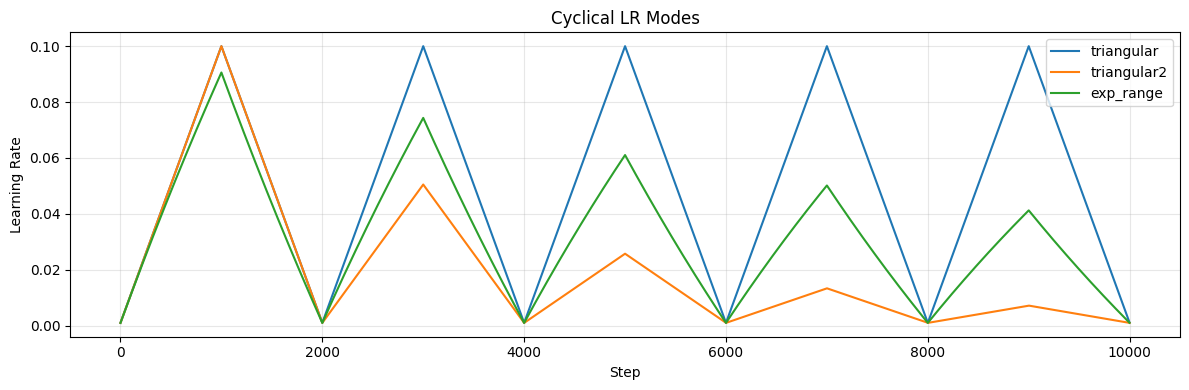

In [6]:
print("Cyclical Learning Rates")
print("=" * 50)

fig, ax = plt.subplots(figsize=(12, 4))
num_steps = 10000

for mode in ['triangular', 'triangular2', 'exp_range']:
    model = nn.Linear(10, 10)
    optimizer = SGD(model.parameters(), lr=0.1)
    gamma = 0.9999 if mode == 'exp_range' else 1.0
    scheduler = CyclicLR(optimizer, base_lr=0.001, max_lr=0.1,
                         step_size_up=1000, mode=mode, gamma=gamma)

    lrs = []
    for _ in range(num_steps):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    ax.plot(lrs, label=mode, linewidth=1.5)

ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Cyclical LR Modes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cyclical_lr.png', dpi=150, bbox_inches='tight')
plt.show()

1Cycle Policy

Super-convergence: warmup → peak → anneal in one cycle.

1Cycle Policy


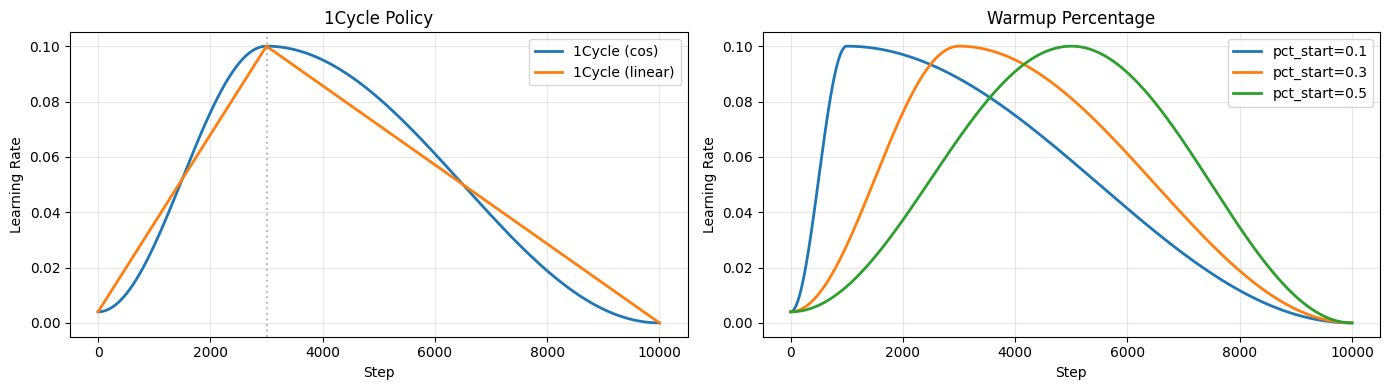

In [7]:
print("1Cycle Policy")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
total_steps = 10000

# Basic 1cycle
ax = axes[0]
for anneal in ['cos', 'linear']:
    model = nn.Linear(10, 10)
    optimizer = SGD(model.parameters(), lr=0.1)
    scheduler = OneCycleLR(optimizer, max_lr=0.1, total_steps=total_steps,
                           pct_start=0.3, anneal_strategy=anneal)
    lrs = []
    for _ in range(total_steps):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    ax.plot(lrs, label=f'1Cycle ({anneal})', linewidth=2)

ax.axvline(total_steps * 0.3, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('1Cycle Policy')
ax.legend()
ax.grid(True, alpha=0.3)

# Different warmup %
ax = axes[1]
for pct in [0.1, 0.3, 0.5]:
    model = nn.Linear(10, 10)
    optimizer = SGD(model.parameters(), lr=0.1)
    scheduler = OneCycleLR(optimizer, max_lr=0.1, total_steps=total_steps, pct_start=pct)
    lrs = []
    for _ in range(total_steps):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    ax.plot(lrs, label=f'pct_start={pct}', linewidth=2)

ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Warmup Percentage')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('one_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

Learning Rate Finder

In [8]:
class LRFinder:

    def __init__(self, model, optimizer, criterion, device):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.initial_state = {
            'model': {k: v.clone() for k, v in model.state_dict().items()},
            'optimizer': optimizer.state_dict()
        }
        self.lrs = []
        self.losses = []

    def find(self, train_loader, start_lr=1e-7, end_lr=10, num_iter=100):
        self.model.train()
        lr_mult = (end_lr / start_lr) ** (1 / num_iter)
        lr = start_lr

        for group in self.optimizer.param_groups:
            group['lr'] = lr

        avg_loss = 0
        best_loss = float('inf')
        batch_iter = iter(train_loader)
        self.lrs, self.losses = [], []

        for i in range(num_iter):
            try:
                data, target = next(batch_iter)
            except StopIteration:
                batch_iter = iter(train_loader)
                data, target = next(batch_iter)

            data, target = data.to(self.device), target.to(self.device)

            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)

            avg_loss = 0.05 * loss.item() + 0.95 * avg_loss
            smoothed = avg_loss / (1 - 0.95 ** (i + 1))

            if i > 0 and smoothed > 4 * best_loss:
                break
            if smoothed < best_loss:
                best_loss = smoothed

            self.lrs.append(lr)
            self.losses.append(smoothed)

            loss.backward()
            self.optimizer.step()

            lr *= lr_mult
            for group in self.optimizer.param_groups:
                group['lr'] = lr

        self.model.load_state_dict(self.initial_state['model'])
        self.optimizer.load_state_dict(self.initial_state['optimizer'])
        return self.lrs, self.losses

    def plot(self):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.lrs[10:-5], self.losses[10:-5], linewidth=2)
        ax.set_xscale('log')
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Loss')
        ax.set_title('LR Finder')
        ax.grid(True, alpha=0.3)

        min_idx = np.argmin(self.losses[10:-5])
        suggested = self.lrs[10:-5][min_idx] / 10
        ax.axvline(suggested, color='red', linestyle='--', label=f'Suggested: {suggested:.2e}')
        ax.legend()
        return fig, suggested

Learning Rate Finder


100%|██████████| 9.91M/9.91M [00:00<00:00, 42.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.37MB/s]


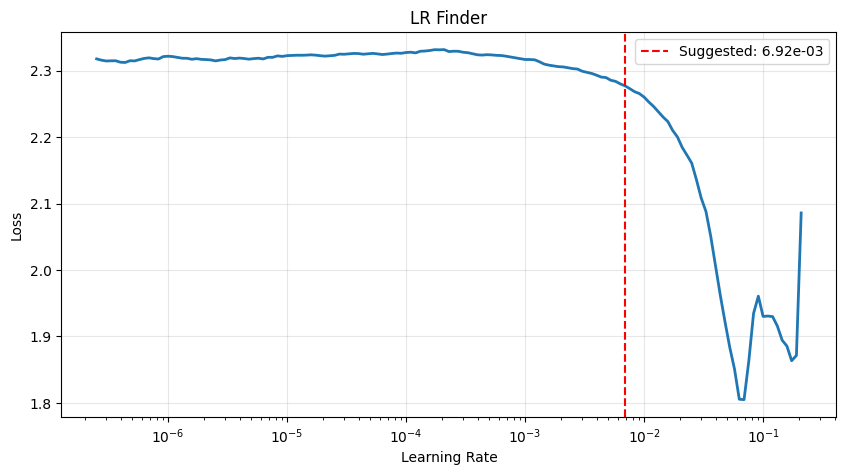

Suggested LR: 0.0069


In [9]:
# Test LR finder
print("Learning Rate Finder")
print("=" * 50)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_subset = Subset(train_dataset, range(5000))
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)

class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = MNISTModel().to(device)
optimizer = SGD(model.parameters(), lr=1e-7, momentum=0.9)
criterion = nn.CrossEntropyLoss()

finder = LRFinder(model, optimizer, criterion, device)
lrs, losses = finder.find(train_loader, num_iter=200)
fig, suggested_lr = finder.plot()
plt.savefig('lr_finder.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Suggested LR: {suggested_lr:.4f}")

Experimental Comparison

In [10]:
def train_with_schedule(schedule_name: str, train_loader, test_loader, epochs=15):
    model = MNISTModel().to(device)
    optimizer = SGD(model.parameters(), lr=0.1, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    steps_per_epoch = len(train_loader)
    total_steps = epochs * steps_per_epoch

    if schedule_name == 'constant':
        scheduler = LambdaLR(optimizer, lambda x: 1.0)
    elif schedule_name == 'step':
        scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    elif schedule_name == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    elif schedule_name == 'onecycle':
        scheduler = OneCycleLR(optimizer, max_lr=0.1, total_steps=total_steps)
    else:
        scheduler = LambdaLR(optimizer, lambda x: 1.0)

    train_losses, test_accs, lrs = [], [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            loss = criterion(model(data), target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            lrs.append(optimizer.param_groups[0]['lr'])
            if schedule_name == 'onecycle':
                scheduler.step()

        if schedule_name != 'onecycle':
            scheduler.step()

        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        correct = sum(model(d.to(device)).argmax(1).eq(t.to(device)).sum().item()
                     for d, t in test_loader)
        test_accs.append(correct / len(test_loader.dataset))

    return {'losses': train_losses, 'accs': test_accs, 'lrs': lrs, 'final': test_accs[-1]}

Comparing Schedules
Training with constant...
  Final accuracy: 0.1170
Training with step...
  Final accuracy: 0.8175
Training with cosine...
  Final accuracy: 0.8775
Training with onecycle...
  Final accuracy: 0.9195


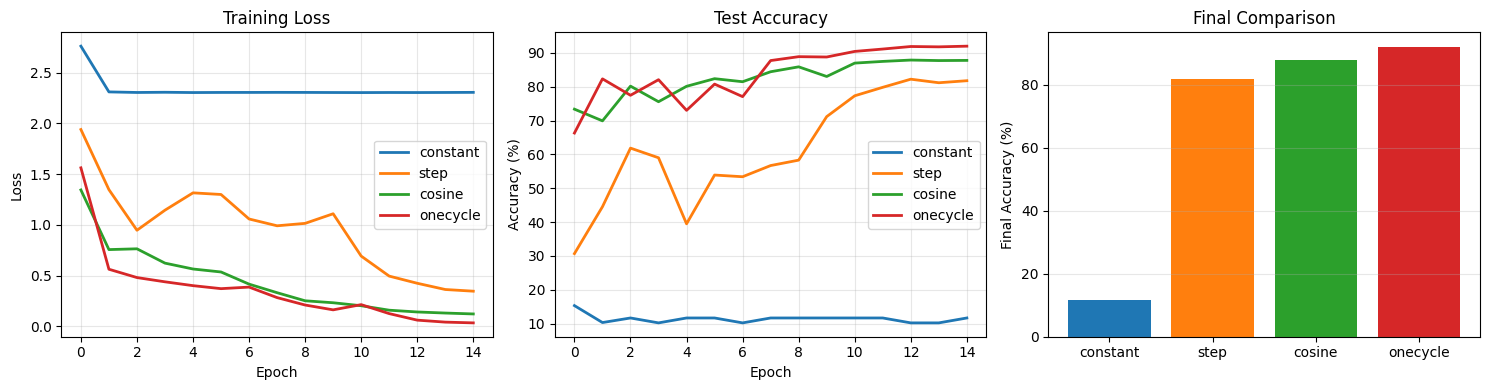

In [11]:
print("Comparing Schedules")
print("=" * 50)

test_dataset = datasets.MNIST('./data', train=False, transform=transform)
test_subset = Subset(test_dataset, range(2000))
test_loader = DataLoader(test_subset, batch_size=128)

schedules = ['constant', 'step', 'cosine', 'onecycle']
results = {}

for name in schedules:
    print(f"Training with {name}...")
    results[name] = train_with_schedule(name, train_loader, test_loader)
    print(f"  Final accuracy: {results[name]['final']:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name, res in results.items():
    axes[0].plot(res['losses'], label=name, linewidth=2)
    axes[1].plot([100*a for a in res['accs']], label=name, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

names = list(results.keys())
accs = [100 * results[n]['final'] for n in names]
axes[2].bar(names, accs, color=plt.cm.tab10(range(len(names))))
axes[2].set_ylabel('Final Accuracy (%)')
axes[2].set_title('Final Comparison')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('schedule_comparison.png', dpi=150, bbox_inches='tight')
plt.show()